**Table of contents**<a id='toc0_'></a>    
- [Photoswitching fingerprints: 4 fluorophores](#toc1_)    
  - [Data generation](#toc1_1_)    
  - [Reading and fitting the data](#toc1_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Photoswitching fingerprints: 4 fluorophores](#toc0_)

In [ ]:
import numpy as np

import fluopy.fluorophores as fl
import fluopy.routines as rt
import fluopy.transitions as tr

%load_ext autoreload
%autoreload 2

saving_at = r""

## <a id='toc1_1_'></a>[Data generation](#toc0_)

In [4]:
def prepare_transition_set():
    fluorophore1 = fl.Fluorophore(name="cy5_dna", position=[0, -2.25])
    fluorophore2 = fl.Fluorophore(name="cy5_dna", position=[0, 2.25])
    fluorophore3 = fl.Fluorophore(name="cy5_dna", position=[-7.677, 0])
    fluorophore4 = fl.Fluorophore(name="cy5_dna", position=[7.677, 0])
    fluorophores = [fluorophore1, fluorophore2, fluorophore3, fluorophore4]
    fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
    transitions = fluorophore_system.load_transitions(
        bleaching=True,
        summarize=True,
        energy_transfer=True,
        **rt.PARAMS_DSTORM,
    )
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set.finalize()

    return transition_set

In [5]:
tr_set = prepare_transition_set()

array([[<Axes: xlabel='x [nm]', ylabel='y [nm]'>]], dtype=object)

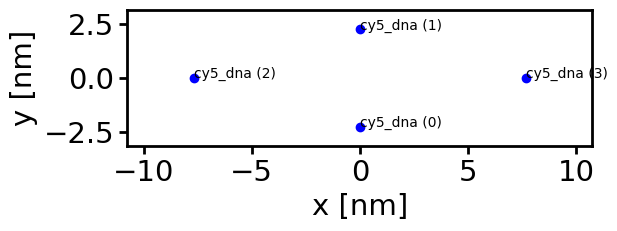

In [6]:
tr_set.fluorophore_system.plot()

In [ ]:
distance = 8.0
rng = np.random.default_rng(1)
transition_set = prepare_transition_set(distance)
_, _, _ = rt.fingerprint_analysis(
    transition_set,
    batch_size=50,
    batches=10,
    filepath=saving_at,
    filename=f"{distance}nm",
    seed=rng,
    use_memmap=r"C:\Users\vie43sq\Desktop\Simulations\memmaps\run_1",
)